In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.dtypes


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [11]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df['TotalCharges'].unique()[:20]

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str

In [13]:
df[df['TotalCharges'] == ' ']



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [14]:
churn_counts = df['Churn'].value_counts()
churn_rate = churn_counts['Yes'] / len(df) * 100
print(f"Churn rate: {churn_rate:.2f}%")

Churn rate: 26.54%


In [15]:
df[df['TotalCharges'] == ' ']['tenure']


488     0
753     0
936     0
1082    0
1340    0
3331    0
3826    0
4380    0
5218    0
6670    0
6754    0
Name: tenure, dtype: int64

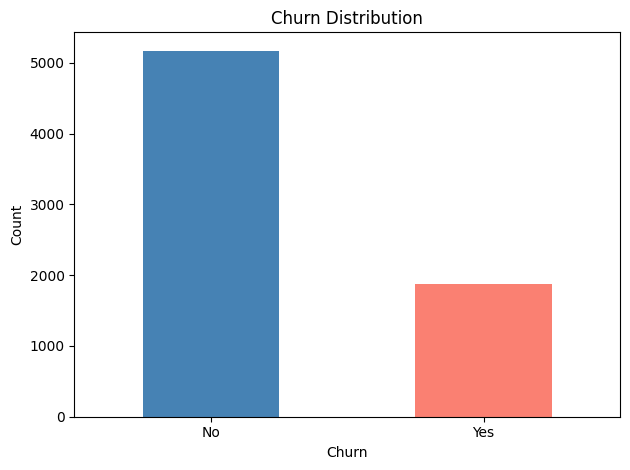

In [16]:
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/churn_distribution.png')
plt.show()


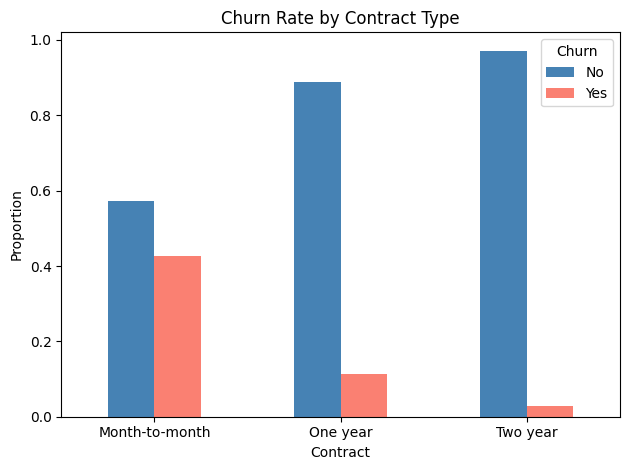

In [17]:
ct = y('Contracdf.groupbt')['Churn'].value_counts(normalize=True).unstack()
ct.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Rate by Contract Type')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/churn_by_contract.png')
plt.show()


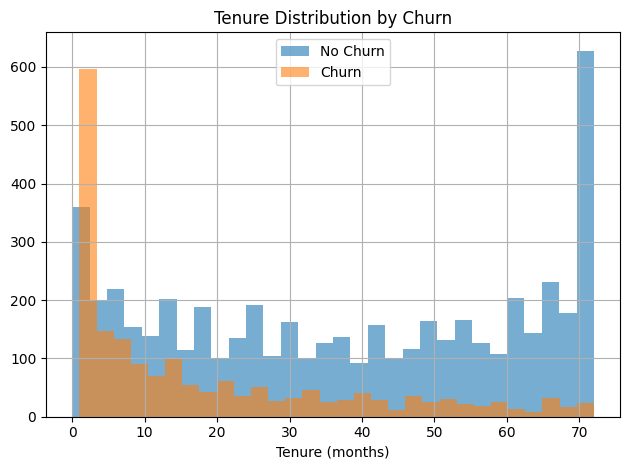

In [18]:
df.groupby('Churn')['tenure'].hist(alpha=0.6, bins=30)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.legend(['No Churn', 'Churn'])
plt.tight_layout()
plt.savefig('../reports/tenure_by_churn.png')
plt.show()

In [ ]:
## Key EDA Findings

##1. Dataset has X rows and 21 columns
##2. Churn rate is 26.54% — class imbalance exists
##3. TotalCharges is stored as string — contains 11 blank values for tenure=0 customers
##4. Month-to-month contracts have significantly higher churn
##5. High churn in early tenure (0-10 months)
##6. Churners tend to have higher monthly charges

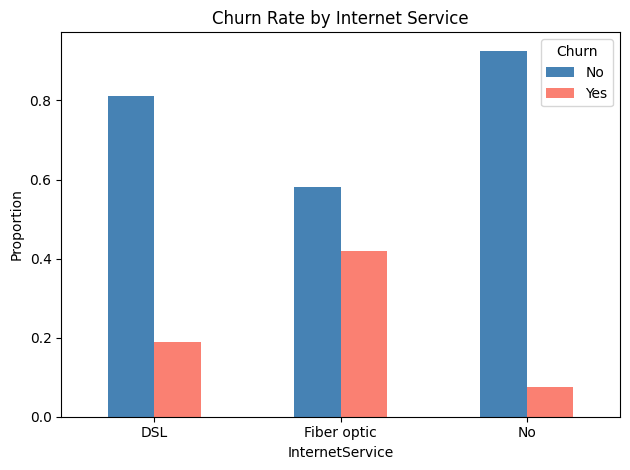

In [20]:
# Churn rate by Internet Service type
ct2 = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()
ct2.plot(kind='bar', color=['steelblue','salmon'])
plt.title('Churn Rate by Internet Service')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/churn_by_internet.png')
plt.show()

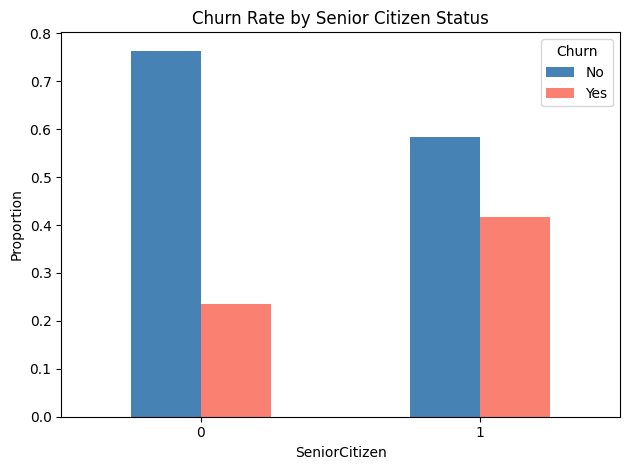

In [21]:
# Senior citizen churn
ct3 = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack()
ct3.plot(kind='bar', color=['steelblue','salmon'])
plt.title('Churn Rate by Senior Citizen Status')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/churn_by_senior.png')
plt.show()